<a href="https://www.kaggle.com/code/trananhhuy0402/video-ai-traffic?scriptVersionId=321498950" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# VIDEO AI TRAFFIC DETECTION

## Import Libraries

In [9]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torchvision
import torchvision.models as models

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

## Dataset Paths and Constant value

In [10]:
DATASET_PATH = "/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset"

TRAIN_IMAGE_DIR = f"{DATASET_PATH}/train/images"
TRAIN_LABEL_DIR = f"{DATASET_PATH}/train/labels"

VALID_IMAGE_DIR = f"{DATASET_PATH}/valid/images"
VALID_LABEL_DIR = f"{DATASET_PATH}/valid/labels"

CLASSES_FILE = f"{DATASET_PATH}/classes.txt"

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

NUM_CLASSES=7

## Dataset info

In [11]:
print("DATASET INFO:")
print(os.listdir(DATASET_PATH))

print("Train images:", len(os.listdir(TRAIN_IMAGE_DIR)))
print("Train labels:", len(os.listdir(TRAIN_LABEL_DIR)))

print("Valid images:", len(os.listdir(VALID_IMAGE_DIR)))
print("Valid labels:", len(os.listdir(VALID_LABEL_DIR)))

with open(CLASSES_FILE, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print("Class:", classes)
print("Num class:", len(classes))

DATASET INFO:
['valid', 'classes.txt', 'train']
Train images: 2100
Train labels: 2100
Valid images: 900
Valid labels: 900
Class: ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']
Num class: 6


## Check Missing Labels

In [12]:
train_images = sorted([
    file
    for file in os.listdir(TRAIN_IMAGE_DIR)
    if file.lower().endswith(VALID_EXTENSIONS)
])

train_labels = sorted(os.listdir(TRAIN_LABEL_DIR))

missing = []

for image_name in train_images:
    label_name = (os.path.splitext(image_name)[0] + ".txt")

    if label_name not in train_labels:
        missing.append(image_name)

print("Missing Labels:", len(missing))

Missing Labels: 0


## Visualize Dataset

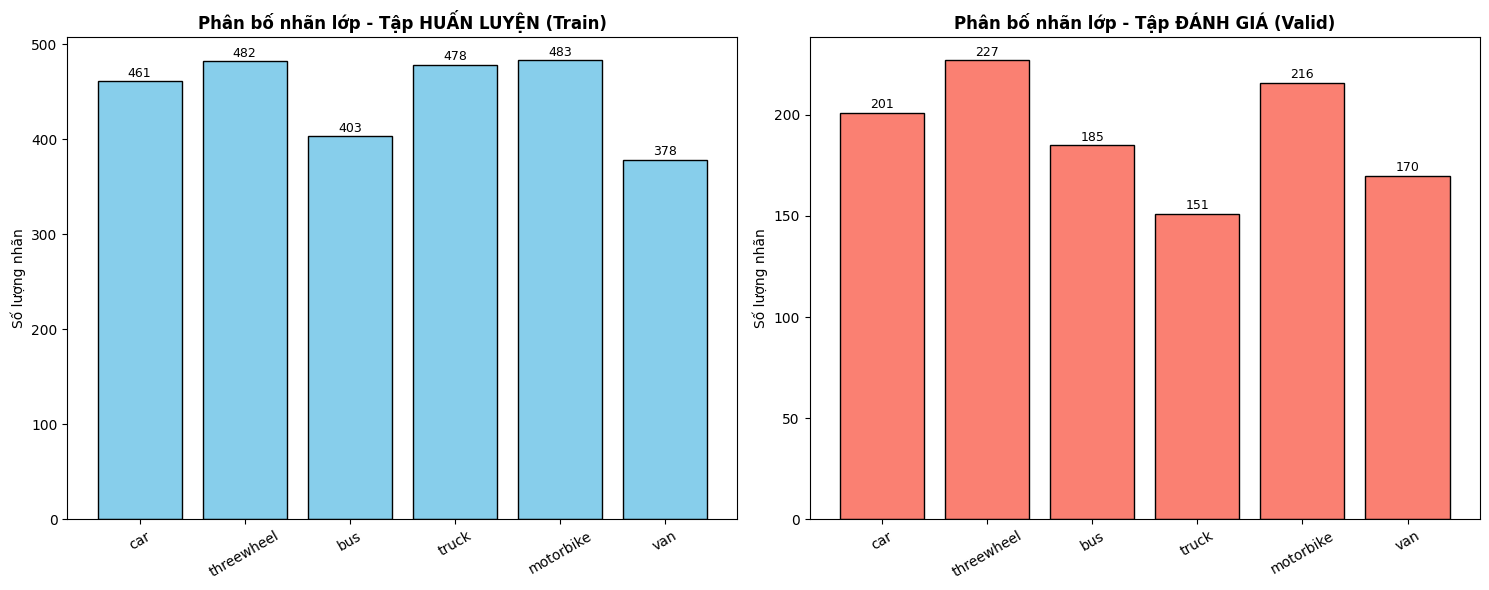

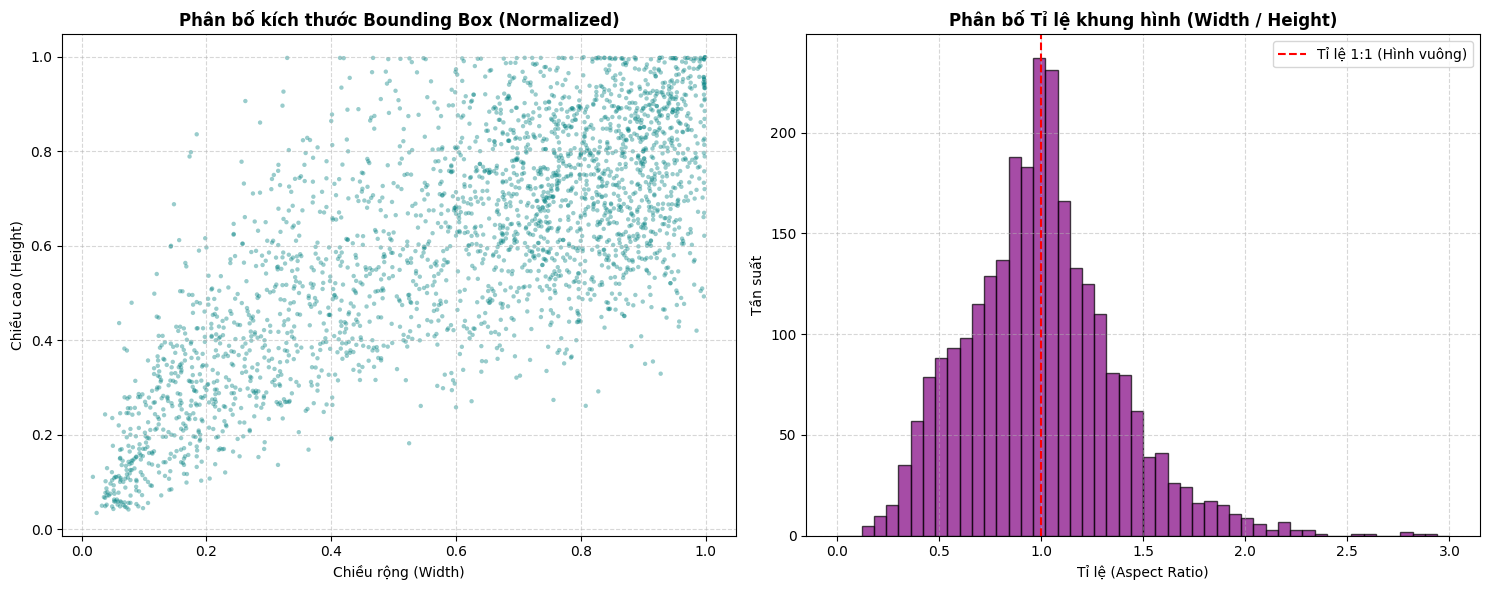

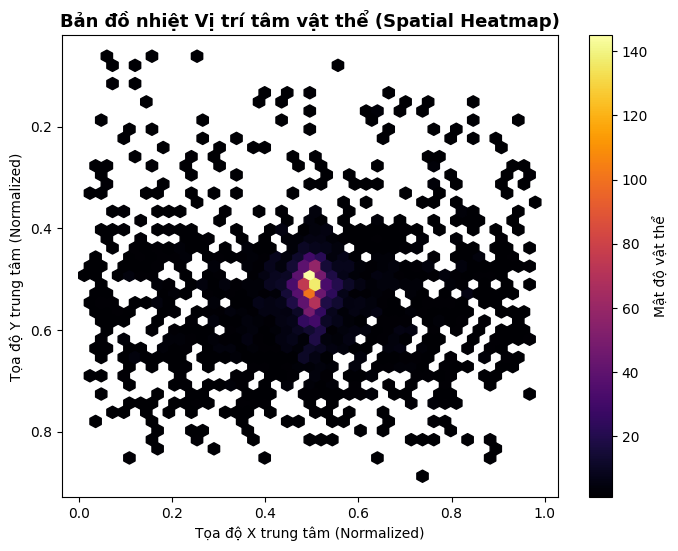

In [13]:
# ------------------------------------------------------
# 1. Thu thập dữ liệu nhãn từ cả hai tập Train và Valid
# -------------------------------------------------------
def collect_bbox_stats(label_dir):
    class_counts = {i: 0 for i in range(len(classes))}
    box_widths = []
    box_heights = []
    center_xs = []
    center_ys = []
    
    for file in os.listdir(label_dir):
        if not file.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:5])
                
                if class_id in class_counts:
                    class_counts[class_id] += 1
                box_widths.append(w)
                box_heights.append(h)
                center_xs.append(x_c)
                center_ys.append(y_c)
                
    return class_counts, box_widths, box_heights, center_xs, center_ys

train_counts, train_w, train_h, train_cx, train_cy = collect_bbox_stats(TRAIN_LABEL_DIR)
valid_counts, valid_w, valid_h, valid_cx, valid_cy = collect_bbox_stats(VALID_LABEL_DIR)

# ----------------------------------------------------
# 2. Vẽ biểu đồ Phân bố các Lớp phương tiện (Class Distribution)
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Train
train_values = [train_counts[i] for i in range(len(classes))]
axes[0].bar(classes, train_values, color='skyblue', edgecolor='black')
axes[0].set_title('Phân bố nhãn lớp - Tập HUẤN LUYỆN (Train)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng nhãn', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(train_values):
    axes[0].text(i, v + max(train_values)*0.01, str(v), ha='center', fontsize=9)

# Valid
valid_values = [valid_counts[i] for i in range(len(classes))]
axes[1].bar(classes, valid_values, color='salmon', edgecolor='black')
axes[1].set_title('Phân bố nhãn lớp - Tập ĐÁNH GIÁ (Valid)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lượng nhãn', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(valid_values):
    axes[1].text(i, v + max(valid_values)*0.01, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## YOLO → XYXY Conversion

In [35]:
def yolo_to_xyxy(box, img_width, img_height):
    x_center, y_center, width, height = box

    x1 = (x_center - width / 2) * img_width
    y1 = (y_center - height / 2) * img_height

    x2 = (x_center + width / 2) * img_width
    y2 = (y_center + height / 2) * img_height

    return [x1, y1, x2, y2]

## Read YOLO Labels

In [36]:
def read_yolo_label(label_path, img_width, img_height):
    boxes = []
    labels = []

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip().split()

        class_id = int(line[0]) + 1

        bbox = list(map(float, line[1:]))

        bbox = yolo_to_xyxy(
            bbox,
            img_width,
            img_height
        )

        boxes.append(bbox)
        labels.append(class_id)

    return boxes, labels

## Visualize Sample One Image

In [ ]:
sample_label = "/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/train/labels/00077.txt"
sample_image = "/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/train/images/00077.jpg"

image = cv2.imread(sample_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

boxes, labels = read_yolo_label(
    label_path=sample_label,
    img_width=w,
    img_height=h
)

for box, label in zip(boxes, labels):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image,
        str(label),
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Label:", labels)

## Custom Dataset Class

In [28]:
class VehicleDataset(Dataset):
    def __init__(self, image_dir, label_dir, image_size=224, is_train=False):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_size = image_size
        self.is_train = is_train
        self.images = sorted([
            file
            for file in os.listdir(image_dir)
            if file.lower().endswith(
                VALID_EXTENSIONS
            )
        ])

        self.color_augment = T.Compose([
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.1),
            T.RandomGrayscale(p=0.2)
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        label_path = os.path.join(
            self.label_dir,
            os.path.splitext(image_name)[0] + ".txt"
        )

        # =====================================
        # READ IMAGE
        # =====================================
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        original_h, original_w, _ = image.shape

        # =====================================
        # READ LABEL
        # =====================================
        boxes, labels = read_yolo_label(
            label_path,
            original_w,
            original_h
        )

        # =====================================
        # RESIZE IMAGE
        # =====================================
        image = cv2.resize(
            image,
            (
                self.image_size,
                self.image_size
            )
        )

        # =====================================
        # RESIZE BBOX
        # =====================================
        scale_x = (self.image_size / original_w)
        scale_y = (self.image_size / original_h)

        resized_boxes = []

        for box in boxes:
            x1, y1, x2, y2 = box

            x1 *= scale_x
            y1 *= scale_y

            x2 *= scale_x
            y2 *= scale_y

            resized_boxes.append([x1, y1, x2, y2])

        boxes = resized_boxes

        # =====================================
        # TO TENSOR
        # =====================================
        image = torch.tensor(image, dtype=torch.float32)
        image = image.permute(2, 0, 1) / 255.0

        if self.is_train:
            image = self.color_augment(image)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

## Create Train & Valid Dataset

In [29]:
train_dataset = VehicleDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_LABEL_DIR,
    is_train=True
)

valid_dataset = VehicleDataset(
    VALID_IMAGE_DIR,
    VALID_LABEL_DIR,
    is_train=False
)

## Collate function

In [31]:
def collate_fn(batch):
    return tuple(zip(*batch))

## Dataloader

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

## FINE-TUNING Detector

In [16]:
class FineTuneDetector(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        
        # =====================================
        # PRETRAINED FASTER R-CNN
        # =====================================
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        )
        
        # =====================================
        # BBOX & CLASSIFICATION HEADS
        # =====================================
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features

        self.model.roi_heads.box_predictor = FastRCNNPredictor(
            in_features, 
            num_classes
        )
        
    def forward(self, images, targets=None):
        return self.model(images, targets)

## Device

In [14]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Create model

In [17]:
model = FineTuneDetector(
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 200MB/s]  


FineTuneDetector(
  (model): FasterRCNN(
    (transform): GeneralizedRCNNTransform(
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        Resize(min_size=(800,), max_size=1333, mode='bilinear')
    )
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=0.0)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): FrozenBatchNorm2d(64, eps=0.0)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): FrozenBatchNorm2d(64, eps=0.0)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
         

## Free backbone

In [ ]:
for param in model.model.backbone.parameters():
    param.requires_grad = False

## Optimizer

In [ ]:
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

## Train function

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    running_loss = 0.0

    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # =====================================
        # FORWARD (Tự động tính Loss)
        # =====================================
        loss_dict = model(images, targets)

        total_loss = sum(loss for loss in loss_dict.values())

        # =====================================
        # BACKPROP (Lan truyền ngược cập nhật trọng số)
        # =====================================
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    epoch_loss = running_loss / len(loader)

    return epoch_loss

## Validation function

In [ ]:
def validate_one_epoch(model, loader, device):
    model.train() 

    running_loss = 0.0

    with torch.no_grad(): 
        for images, targets in tqdm(loader):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            total_loss = sum(loss for loss in loss_dict.values())

            running_loss += total_loss.item()

    epoch_loss = running_loss / len(loader)

    return epoch_loss

## Training loop

In [ ]:
NUM_EPOCHS = 10

train_losses = []
valid_losses = []

best_valid_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    # =====================================
    # TRAIN
    # =====================================
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    # =====================================
    # VALID
    # =====================================
    valid_loss = validate_one_epoch(
        model,
        valid_loader,
        device
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")

    # =====================================
    # SAVE BEST MODEL
    # =====================================
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            "best_detector.pth"
        )

        print("Best model saved!")

## Plot training curve

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    valid_losses,
    label="Valid Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

## Load model

In [18]:
model.load_state_dict(
    torch.load(
        "/kaggle/input/notebooks/trananhhuy0402/video-ai-traffic/best_detector.pth"
    )
)

model.eval()

FineTuneDetector(
  (model): FasterRCNN(
    (transform): GeneralizedRCNNTransform(
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        Resize(min_size=(800,), max_size=1333, mode='bilinear')
    )
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=0.0)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): FrozenBatchNorm2d(64, eps=0.0)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): FrozenBatchNorm2d(64, eps=0.0)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
         

## Inference function

In [21]:
def predict_image(model, image_path, device, confidence_threshold=0.5, image_size=224):
    image = cv2.imread(image_path)
    
    original_image = image.copy()
    original_h, original_w, _ = image.shape
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    resized_image = cv2.resize(image, (image_size, image_size))
    
    tensor = torch.tensor(resized_image, dtype=torch.float32)
    tensor = tensor.permute(2, 0, 1) / 255.0
    tensor = tensor.to(device)
    
    model.eval()
    with torch.no_grad():
        predictions = model([tensor])
    
    pred_dict = predictions[0]
    
    boxes = pred_dict['boxes'].cpu().numpy()
    labels = pred_dict['labels'].cpu().numpy()
    scores = pred_dict['scores'].cpu().numpy()
    
    keep_idx = scores >= confidence_threshold
    final_boxes = boxes[keep_idx]
    final_labels = labels[keep_idx]
    final_scores = scores[keep_idx]

    final_boxes_tensor = torch.tensor(final_boxes)
    final_scores_tensor = torch.tensor(final_scores)
    
    # Những khung nào đè lên nhau > 30% (0.3) thì xóa hết, chỉ giữ lại khung tự tin cao nhất!
    nms_keep_idx = torchvision.ops.nms(final_boxes_tensor, final_scores_tensor, iou_threshold=0.3)
    
    final_boxes = final_boxes[nms_keep_idx.numpy()]
    final_labels = final_labels[nms_keep_idx.numpy()]
    final_scores = final_scores[nms_keep_idx.numpy()]
    
    scale_x = original_w / image_size
    scale_y = original_h / image_size
    
    rescaled_boxes = []
    for box in final_boxes:
        x1, y1, x2, y2 = box
        rescaled_boxes.append([x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y])
    
    return original_image, rescaled_boxes, final_labels, final_scores

## Visualize multiple prediction

Đang phân tích ảnh: H5FTQUT8843N.jpg
-> Tổng số khung mô hình đoán ra: 1
-> Độ tự tin của 5 khung đầu tiên: [0.99351984]
-> Tọa độ khung đầu tiên: [np.float32(94.8634), np.float32(28.560389), np.float32(611.7762), np.float32(289.41086)]


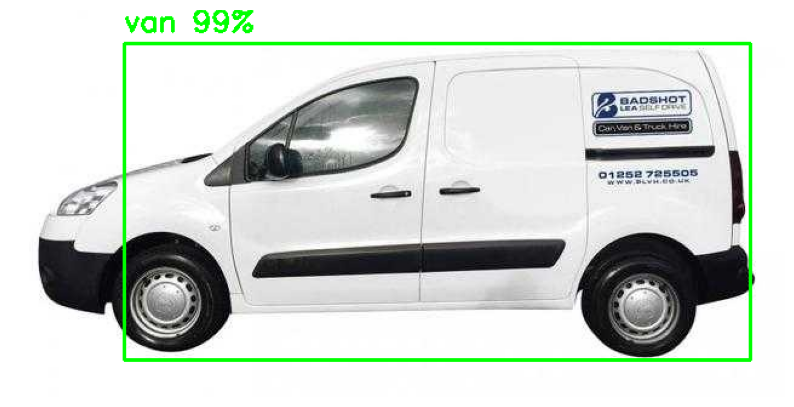

In [22]:
test_image = random.choice(os.listdir(VALID_IMAGE_DIR))
test_image_path = os.path.join(VALID_IMAGE_DIR, test_image)

print(f"Đang phân tích ảnh: {test_image}")

image, pred_boxes, pred_labels, pred_scores = predict_image(
    model,
    test_image_path,
    device
)

print(f"-> Tổng số khung mô hình đoán ra: {len(pred_boxes)}")
if len(pred_scores) > 0:
    print(f"-> Độ tự tin của 5 khung đầu tiên: {pred_scores[:5]}")
    print(f"-> Tọa độ khung đầu tiên: {pred_boxes[0]}")
else:
    print("Không tìm thấy")

for i in range(len(pred_boxes)):
    box = pred_boxes[i]
    label_id = pred_labels[i]
    score = pred_scores[i]
    
    x1, y1, x2, y2 = map(int, box)
        
    class_name = classes[label_id - 1]
    text = f"{class_name} {score * 100:.0f}%"
    
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    cv2.putText(
        image, 
        text, 
        (x1, y1 - 10), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        0.8,
        (0, 255, 0), 
        2
    )

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()